# LQR Solver — Optimal Execution & Markowitz Portfolio

`lqr_solver.py` is the only external file needed. It accepts raw matrices `(A, B, Q, R, M, s0)` and works for any finite-horizon LQR problem via backward induction.

CVXPY, an open source Python-embedded modeling language for convex optimization problems, is used as a verification tool to confirm the LQR solution is correct.

| Section | Problem | State |
|:---|:---|:---|
| A | Optimal Execution (single asset) | 3-D augmented `[w, alpha, c]` |
| B | Multi-Asset Markowitz Portfolio | (n+1)-D augmented `[w, 1]` |

---
## 0  Imports

In [ ]:
import sys, os
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import time

# Remove any cached imports
if 'lqr' in sys.modules:
    del sys.modules['lqr']
if 'lqr.solver' in sys.modules:
    del sys.modules['lqr.solver']

# Clear the path and re-add
NOTEBOOK_DIR = os.getcwd()
PARENT_DIR = os.path.dirname(NOTEBOOK_DIR)

if PARENT_DIR not in sys.path:
    sys.path.insert(0, PARENT_DIR)

# Now import
from lqr import solve_and_execute_lqr

print("Import successful!")

plt.style.use('dark_background')
COLORS = {
    'dp': '#00BFFF',
    'cvx': '#FF6347',
    'target': '#FFD700',
    'gold': '#FFD700',
}
ASSET_PALETTE = ['#00BFFF','#FF6347','#FFD700','#DA70D6','#7FFF00',
                 '#FF8C00','#20B2AA','#FF1493','#ADFF2F','#BA55D3']

def style_ax(ax):
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.grid(color='gray', ls=':', alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

os.makedirs('result', exist_ok=True)
print('Ready.')

Import successful!
Ready.


---
# Part A — Optimal Execution

## Problem Overview

At each step the agent holds a position $w_t$, observes a decaying alpha signal $\alpha_t$,
and chooses a trade $u_t$ to balance three competing forces:

| Force | Intuition | Cost term |
|:---|:---|:---|
| **Alpha capture** | Trade in the signal direction while it lasts | $-\alpha_t u_t$ (reward) |
| **Risk** | Large positions expose us to volatility | $\frac{1}{2}\gamma\sigma^2 w_{t+1}^2$ |
| **Execution impact** | Past trades leave lingering market impact | $u^\top Q_{\text{ow}}\, u$ |

---
## State, Control & Dynamics

$$s_t = \begin{bmatrix} w_t \\ \alpha_t \\ c_t \end{bmatrix} \qquad u_t = \delta w_t$$

| Symbol | Meaning |
|:---|:---|
| $w_t$ | Current position |
| $\alpha_t$ | Predictive signal — decays as $\alpha_{t+1} = \rho\,\alpha_t$ |
| $c_t$ | Accumulated impact from past trades — decays as $c_{t+1} = \beta c_t + \beta\eta u_t$ |
| $u_t$ | Trade size (control action) |

The full transition $s_{t+1} = A s_t + B u_t$ is:

$$\begin{bmatrix} w_{t+1} \\ \alpha_{t+1} \\ c_{t+1} \end{bmatrix}
=
\underbrace{\begin{bmatrix} 1 & 0 & 0 \\ 0 & \rho & 0 \\ 0 & 0 & \beta \end{bmatrix}}_{A}
\begin{bmatrix} w_t \\ \alpha_t \\ c_t \end{bmatrix}
+
\underbrace{\begin{bmatrix} 1 \\ 0 \\ \beta\eta \end{bmatrix}}_{B} u_t$$

> **Key insight:** Expanding the $c$ recursion over all steps gives $\sum_t c_t u_t = u^\top Q_{\text{ow}}^{\text{off-diag}} u$.
> Combined with the $R$ diagonal, the LQR solves the **exact same objective** as a direct CVXPY formulation — no approximation.

---
## LQR Cost Matrices

Per-step cost: $\;s_t^\top Q\, s_t \;+\; u_t^\top R\, u_t \;+\; 2\,s_t^\top M\, u_t$ = $\begin{bmatrix} s_t \\ u_t \end{bmatrix}^\top \underbrace{\begin{bmatrix} Q & M \\ M^\top & R \end{bmatrix}}_{H} \begin{bmatrix} s_t \\ u_t \end{bmatrix}$

| Matrix | Shape | Value | What it encodes |
|:---|:---|:---|:---|
| $Q$ | $(3,3)$ | `diag([0.5γσ², 0, 0])` | Risk penalty on holding position $w_t$ |
| $R$ | $(1,1)$ | `[[0.5γσ² + 0.5η]]` | Risk + execution cost on trade $u_t$ |
| $M$ | $(3,1)$ | `[[0.5γσ²], [-0.5], [0.5]]` | Links: risk cross-term, alpha reward, impact kernel |
| $s_0$ | $(3,)$ | `[0, α₀, 0]` | Start flat, with initial signal, zero impact |

**H must be positive semi-definite** for the problem to be convex and well-posed.

---


## A1  Parameters & Matrices

In [2]:
# ════════════════════════════════════════════════════════
#  Edit parameters here
# ════════════════════════════════════════════════════════
T_ex        = 30
gamma_ex    = 1.0
sigma_sq_ex = 0.04
eta_ex      = 0.1
rho_ex      = 0.95
beta_ex     = 0.8
alpha0_ex   = 1.0
# ════════════════════════════════════════════════════════

A_ex = np.array([[1.0,  0.0,      0.0    ],
                 [0.0,  rho_ex,   0.0    ],
                 [0.0,  0.0,      beta_ex]])

B_ex = np.array([[1.0            ],
                 [0.0            ],
                 [beta_ex*eta_ex ]])

Q_ex  = np.diag([0.5*gamma_ex*sigma_sq_ex, 0.0, 0.0])
R_ex  = np.array([[0.5*gamma_ex*sigma_sq_ex + 0.5*eta_ex]])
M_ex  = np.array([[0.5*gamma_ex*sigma_sq_ex], [-0.5], [0.5]])
s0_ex = np.array([0.0, alpha0_ex, 0.0])

print(f'T={T_ex}, gamma={gamma_ex}, sigma_sq={sigma_sq_ex}, eta={eta_ex}, rho={rho_ex}, beta={beta_ex}, alpha0={alpha0_ex}')

T=30, gamma=1.0, sigma_sq=0.04, eta=0.1, rho=0.95, beta=0.8, alpha0=1.0


## A2  Solve (LQR) + Verify (CVXPY)

In [3]:
# ── LQR — median timing over N_REPEAT runs ───────────────
N_REPEAT = 100

times_lqr = []
for _ in range(N_REPEAT):
    t0 = time.perf_counter()
    result_ex = solve_and_execute_lqr(T_ex, A_ex, B_ex, Q_ex, R_ex, M_ex, s0_ex)
    times_lqr.append((time.perf_counter() - t0) * 1000)

time_lqr_ex = np.median(times_lqr)
# Extract trajectories from result
s_lqr_ex = result_ex.s_path
u_lqr_ex = result_ex.u_path
w_lqr_ex = s_lqr_ex[1:, 0]
u_lqr_ex_w = u_lqr_ex[:, 0]

# ── CVXPY — median timing over N_REPEAT runs ─────────────
# Identical objective to LQR:
#   -alphas'u  +  0.5*gamma*sigma_sq*sum(w_t^2)  +  u'*Q_ow*u
alphas_ex = alpha0_ex * (rho_ex ** np.arange(T_ex))
i_idx, j_idx = np.indices((T_ex, T_ex))
Q_ow = (eta_ex / 2.0) * (beta_ex ** np.abs(i_idx - j_idx))

times_cvx = []
for _ in range(N_REPEAT):
    t0 = time.perf_counter()
    u_v = cp.Variable(T_ex)
    w_v = cp.Variable(T_ex)
    con_ex = [w_v[0] == u_v[0]]
    for t in range(1, T_ex):
        con_ex.append(w_v[t] == w_v[t-1] + u_v[t])
    cost_ex = (-alphas_ex @ u_v
               + 0.5*gamma_ex*sigma_sq_ex * cp.sum_squares(w_v)
               + cp.quad_form(u_v, Q_ow))
    cp.Problem(cp.Minimize(cost_ex), con_ex).solve(
        solver=cp.OSQP, warm_starting=False)
    times_cvx.append((time.perf_counter() - t0) * 1000)

time_cvx_ex = np.median(times_cvx)
w_cvx_ex = w_v.value
u_cvx_ex_w = u_v.value
diff_ex = w_lqr_ex - w_cvx_ex
speedup_ex = time_cvx_ex / time_lqr_ex

obj_lqr_ex = float(-alphas_ex @ u_lqr_ex_w
                   + 0.5*gamma_ex*sigma_sq_ex*np.sum(w_lqr_ex**2)
                   + u_lqr_ex_w @ Q_ow @ u_lqr_ex_w)
obj_cvx_ex = float(-alphas_ex @ u_cvx_ex_w
                   + 0.5*gamma_ex*sigma_sq_ex*np.sum(w_cvx_ex**2)
                   + u_cvx_ex_w @ Q_ow @ u_cvx_ex_w)

from IPython.display import Markdown, display
display(Markdown(
    f'| Method | Time (ms) | Objective | Speedup |\n'
    f'|:---|---:|---:|---:|\n'
    f'| **CVXPY (verify)** | {time_cvx_ex:.2f} | {obj_cvx_ex:.6f} | 1x |\n'
    f'| **LQR (main)** | {time_lqr_ex:.2f} | {obj_lqr_ex:.6f} | **~{speedup_ex:.0f}x** |'
))

| Method | Time (ms) | Objective | Speedup |
|:---|---:|---:|---:|
| **CVXPY (verify)** | 46.62 | -0.527816 | 1x |
| **LQR (main)** | 1.11 | -0.527816 | **~42x** |

## A3  Plots

Saved: result/execution_results.png


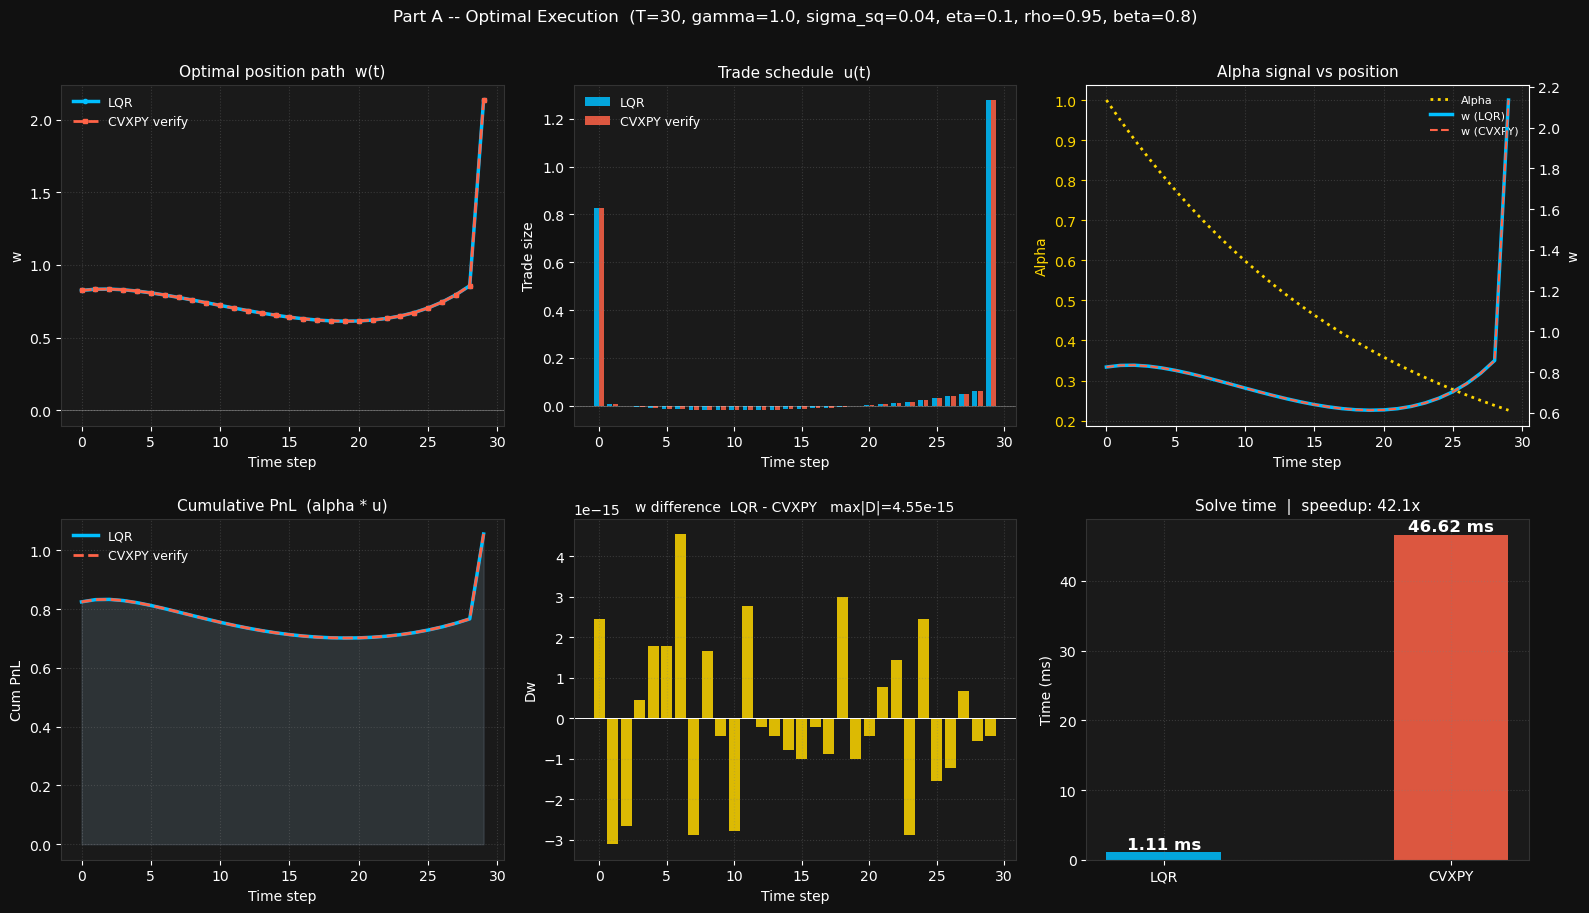

In [4]:
steps_ex = np.arange(T_ex)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor('#111111')
axes = axes.flatten()
for ax in axes: style_ax(ax)

# 1 — Position paths
axes[0].plot(steps_ex, w_lqr_ex, color=COLORS['dp'],  lw=2.5, marker='o', ms=3, label='LQR')
axes[0].plot(steps_ex, w_cvx_ex, color=COLORS['cvx'], lw=2,   marker='s', ms=3, ls='--', label='CVXPY verify')
axes[0].axhline(0, color='white', lw=0.5, alpha=0.4)
axes[0].set_title('Optimal position path  w(t)', color='white', fontsize=11)
axes[0].set_xlabel('Time step', color='white'); axes[0].set_ylabel('w', color='white')
axes[0].legend(frameon=False, fontsize=9)

# 2 — Trade schedule
axes[1].bar(steps_ex - 0.2, u_lqr_ex_w, width=0.35, color=COLORS['dp'],  alpha=0.85, label='LQR')
axes[1].bar(steps_ex + 0.2, u_cvx_ex_w, width=0.35, color=COLORS['cvx'], alpha=0.85, label='CVXPY verify')
axes[1].axhline(0, color='white', lw=0.5, alpha=0.4)
axes[1].set_title('Trade schedule  u(t)', color='white', fontsize=11)
axes[1].set_xlabel('Time step', color='white'); axes[1].set_ylabel('Trade size', color='white')
axes[1].legend(frameon=False, fontsize=9)

# 3 — Alpha vs position
ax3r = axes[2].twinx()
axes[2].plot(steps_ex, alphas_ex, color=COLORS['gold'], lw=2, ls=':', label='Alpha')
ax3r.plot(steps_ex, w_lqr_ex, color=COLORS['dp'],  lw=2.5, label='w (LQR)')
ax3r.plot(steps_ex, w_cvx_ex, color=COLORS['cvx'], lw=1.5, ls='--', label='w (CVXPY)')
axes[2].set_title('Alpha signal vs position', color='white', fontsize=11)
axes[2].set_xlabel('Time step', color='white')
axes[2].set_ylabel('Alpha', color=COLORS['gold']); axes[2].tick_params(axis='y', colors=COLORS['gold'])
ax3r.set_ylabel('w', color='white'); ax3r.tick_params(colors='white')
l1, b1 = axes[2].get_legend_handles_labels()
l2, b2 = ax3r.get_legend_handles_labels()
axes[2].legend(l1+l2, b1+b2, frameon=False, fontsize=8)

# 4 — Cumulative PnL
cum_lqr = np.cumsum(alphas_ex * u_lqr_ex_w)
cum_cvx = np.cumsum(alphas_ex * u_cvx_ex_w)
axes[3].plot(steps_ex, cum_lqr, color=COLORS['dp'],  lw=2.5, label='LQR')
axes[3].plot(steps_ex, cum_cvx, color=COLORS['cvx'], lw=2, ls='--', label='CVXPY verify')
axes[3].fill_between(steps_ex, cum_lqr, alpha=0.12, color=COLORS['dp'])
axes[3].fill_between(steps_ex, cum_cvx, alpha=0.10, color=COLORS['cvx'])
axes[3].set_title('Cumulative PnL  (alpha * u)', color='white', fontsize=11)
axes[3].set_xlabel('Time step', color='white'); axes[3].set_ylabel('Cum PnL', color='white')
axes[3].legend(frameon=False, fontsize=9)

# 5 — Difference
axes[4].bar(steps_ex, diff_ex, color=COLORS['gold'], alpha=0.85)
axes[4].axhline(0, color='white', lw=0.7)
axes[4].set_title(f'w difference  LQR - CVXPY   max|D|={np.abs(diff_ex).max():.2e}',
                  color='white', fontsize=10)
axes[4].set_xlabel('Time step', color='white'); axes[4].set_ylabel('Dw', color='white')

# 6 — Timing bar
bars = axes[5].bar(['LQR','CVXPY'], [time_lqr_ex, time_cvx_ex],
                   color=[COLORS['dp'], COLORS['cvx']], width=0.4, alpha=0.85)
for bar, t in zip(bars, [time_lqr_ex, time_cvx_ex]):
    axes[5].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{t:.2f} ms', ha='center', va='bottom',
                 color='white', fontsize=12, fontweight='bold')
axes[5].set_title(f'Solve time  |  speedup: {speedup_ex:.1f}x', color='white', fontsize=11)
axes[5].set_ylabel('Time (ms)', color='white')

fig.suptitle(
    f'Part A -- Optimal Execution  (T={T_ex}, gamma={gamma_ex}, sigma_sq={sigma_sq_ex}, eta={eta_ex}, rho={rho_ex}, beta={beta_ex})',
    color='white', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('result/execution_results.png', dpi=150, bbox_inches='tight', facecolor='#111111')
print('Saved: result/execution_results.png')
plt.show()

---
# Part B — Multi-Asset Markowitz Portfolio

## Problem Overview

At each step the agent holds a portfolio $w_t \in \mathbb{R}^n$ and chooses trades $u_t$ to balance:

| Force | Intuition | Cost term |
|:---|:---|:---|
| **Expected return** | Move toward high-$\mu$ assets | $-\mu^\top w_{t+1}$ (reward) |
| **Risk** | Penalise portfolio variance | $\frac{\lambda}{2}\, w_{t+1}^\top \Sigma\, w_{t+1}$ |
| **Transaction cost** | Penalise large trades | $\frac{\gamma_{tc}}{2}\|u_t\|^2$ |

---
## State, Control & Dynamics

$$s_t = \begin{bmatrix} w_t \\ 1 \end{bmatrix} \in \mathbb{R}^{n+1} \qquad u_t = \Delta w_t \in \mathbb{R}^n$$

| Symbol | Meaning |
|:---|:---|
| $w_t \in \mathbb{R}^n$ | Portfolio weights across $n$ assets |
| $1$ | Constant augmentation dimension — encodes the linear $\mu$ reward as a quadratic cross-term |
| $u_t$ | Trade vector — how much to buy/sell each asset |

The full transition $s_{t+1} = A s_t + B u_t$ is:

$$\begin{bmatrix} w_{t+1} \\ 1 \end{bmatrix}
=
\underbrace{\begin{bmatrix} I_n & 0 \\ 0 & 1 \end{bmatrix}}_{A = I_{n+1}}
\begin{bmatrix} w_t \\ 1 \end{bmatrix}
+
\underbrace{\begin{bmatrix} I_n \\ 0 \end{bmatrix}}_{B}
u_t$$

> **Key insight:** The constant `1` dimension never changes ($A_{n,n}=1$, $B_{n,:}=0$).
> It lets us encode the linear term $-\mu^\top w$ inside $Q$ and $M$ as quadratic cross-terms,
> so the standard LQR backward induction applies without modification.

---
## LQR Cost Matrices

Per-step cost: $\;s_t^\top Q\, s_t \;+\; u_t^\top R\, u_t \;+\; 2\,s_t^\top M\, u_t$

| Matrix | Shape | Value | What it encodes |
|:---|:---|:---|:---|
| $Q$ | $(n{+}1, n{+}1)$ | `Q[:n,:n]=0.5λΣ`, `Q[n,:n]=Q[:n,n]=-0.5μ` | Risk + expected return (via constant dim) |
| $R$ | $(n, n)$ | `0.5γ_tc I + 0.5λΣ` | Transaction cost + risk from the trade itself |
| $M$ | $(n{+}1, n)$ | `M[:n,:]=0.5λΣ`, `M[n,:]=-0.5μ` | Risk cross-term + return-from-trade |
| $s_0$ | $(n{+}1,)$ | `[w0, 1]` | Initial weights + constant augmentation |

---


## B1  Parameters & Matrices

In [5]:
# ════════════════════════════════════════════════════════
#  Option 1 — random parameters
# ════════════════════════════════════════════════════════
T_mw     = 30
n_assets = 5
lam      = 2.0
gamma_tc = 0.5
seed     = 42

rng   = np.random.default_rng(seed)
L     = rng.standard_normal((n_assets, n_assets)) * 0.1
Sigma = L @ L.T + np.diag(rng.uniform(0.01, 0.05, n_assets))
mu    = rng.uniform(0.002, 0.010, n_assets)
w0_mw = rng.uniform(-0.05, 0.05, n_assets)

# ════════════════════════════════════════════════════════
#  Option 2 — paste your own matrices
#  mu    = np.array([...])         # (n,)
#  Sigma = np.array([[...], ...])  # (n, n) positive definite
#  w0_mw = np.array([...])         # (n,) initial weights
# ════════════════════════════════════════════════════════

n  = n_assets
na = n + 1

A_mw = np.eye(na)
B_mw = np.vstack([np.eye(n), np.zeros((1, n))])

Q_mw             = np.zeros((na, na))
Q_mw[:n, :n]     = 0.5 * lam * Sigma
Q_mw[n,  :n]     = -0.5 * mu
Q_mw[:n,  n]     = -0.5 * mu

R_mw = 0.5 * gamma_tc * np.eye(n) + 0.5 * lam * Sigma

M_mw             = np.zeros((na, n))
M_mw[:n, :]      = 0.5 * lam * Sigma
M_mw[n,  :]      = -0.5 * mu

s0_mw = np.append(w0_mw, 1.0)

print(f'n={n_assets} assets  T={T_mw}  lam={lam}  gamma_tc={gamma_tc}')
print(f'mu           = {mu.round(4)}')
print(f'w0           = {w0_mw.round(4)}')
print(f'Sigma (diag) = {np.diag(Sigma).round(4)}')

n=5 assets  T=30  lam=2.0  gamma_tc=0.5
mu           = [0.008  0.0097 0.0046 0.005  0.0058]
w0           = [-0.0311 -0.037  -0.0024 -0.0273  0.017 ]
Sigma (diag) = [0.0821 0.0541 0.0405 0.0419 0.0593]


## B2  Solve (LQR) + Verify (CVXPY)

In [6]:
# ── LQR — median timing over N_REPEAT runs ───────────────
N_REPEAT = 100

times_lqr = []
for _ in range(N_REPEAT):
    t0 = time.perf_counter()
    result_mw = solve_and_execute_lqr(T_mw, A_mw, B_mw, Q_mw, R_mw, M_mw, s0_mw)
    times_lqr.append((time.perf_counter() - t0) * 1000)

time_lqr_mw = np.median(times_lqr)
# Extract state path and drop augmented dimension
s_lqr_mw = result_mw.s_path
w_lqr_mw = s_lqr_mw[:, :n_assets]   # drop augmented dim

# ── CVXPY — median timing over N_REPEAT runs ─────────────
# Wrapped in a function so CVXPY builds a completely fresh
# problem each call — avoids solver caching distorting timing.
def _solve_cvxpy_markowitz(T, mu, Sigma, lam, gamma_tc, w0):
    n_ = len(mu)
    W  = cp.Variable((T + 1, n_))
    U  = cp.Variable((T, n_))
    con  = [W[0] == w0]
    cost = 0
    for t in range(T):
        con.append(W[t+1] == W[t] + U[t])
        cost += (-mu @ W[t+1]
                 + 0.5 * lam      * cp.quad_form(W[t+1], Sigma)
                 + 0.5 * gamma_tc * cp.sum_squares(U[t]))
    cp.Problem(cp.Minimize(cost), con).solve(
        solver=cp.OSQP, warm_starting=False)
    return W.value

times_cvx = []
for _ in range(N_REPEAT):
    t0 = time.perf_counter()
    w_cvx_mw = _solve_cvxpy_markowitz(T_mw, mu, Sigma, lam, gamma_tc, w0_mw)
    times_cvx.append((time.perf_counter() - t0) * 1000)

time_cvx_mw = np.median(times_cvx)

def compute_obj(w_path, mu, Sigma, lam, gamma_tc):
    total = 0.0
    for t in range(1, len(w_path)):
        dw = w_path[t] - w_path[t-1]
        total += (mu @ w_path[t]
                  - 0.5 * lam      * w_path[t] @ Sigma @ w_path[t]
                  - 0.5 * gamma_tc * dw @ dw)
    return total

obj_lqr    = compute_obj(w_lqr_mw, mu, Sigma, lam, gamma_tc)
obj_cvx    = compute_obj(w_cvx_mw, mu, Sigma, lam, gamma_tc)
speedup_mw = time_cvx_mw / time_lqr_mw

from IPython.display import Markdown, display
display(Markdown(
    f'### Multi-Asset Markowitz, n={n_assets}\n\n'
    f'| Method | Time (ms) | Objective | Speedup |\n'
    f'|:---|---:|---:|---:|\n'
    f'| **CVXPY (verify)** | {time_cvx_mw:.2f} | {obj_cvx:.6f} | 1x |\n'
    f'| **LQR (main)** | {time_lqr_mw:.2f} | {obj_lqr:.6f} | **~{speedup_mw:.0f}x** |'
))

### Multi-Asset Markowitz, n=5

| Method | Time (ms) | Objective | Speedup |
|:---|---:|---:|---:|
| **CVXPY (verify)** | 161.69 | 0.030336 | 1x |
| **LQR (main)** | 1.34 | 0.030336 | **~121x** |

In [7]:
# ── Scaling Analysis: Speedup for each n ─────────────────
print("\nRunning scaling analysis across different asset counts...")

n_list = [2, 3, 5, 7, 10, 15, 20]
N_TRIALS = 10
scaling_results = []

for n_ in n_list:
    ts_lqr, ts_cvx = [], []
    for seed_ in range(N_TRIALS):
        rng_  = np.random.default_rng(seed_)
        L_    = rng_.standard_normal((n_, n_)) * 0.1
        Sig_  = L_ @ L_.T + np.diag(rng_.uniform(0.01, 0.05, n_))
        mu_   = rng_.uniform(0.002, 0.010, n_)
        w0_   = rng_.uniform(-0.05, 0.05, n_)
        na_   = n_ + 1
        A_    = np.eye(na_)
        B_    = np.vstack([np.eye(n_), np.zeros((1, n_))])
        Q_    = np.zeros((na_, na_))
        Q_[:n_,:n_]   = 0.5*lam*Sig_
        Q_[na_-1,:n_] = -0.5*mu_; Q_[:n_,na_-1] = -0.5*mu_
        R_    = 0.5*gamma_tc*np.eye(n_) + 0.5*lam*Sig_
        M_    = np.zeros((na_, n_))
        M_[:n_,:] = 0.5*lam*Sig_; M_[na_-1,:] = -0.5*mu_
        s0_   = np.append(w0_, 1.0)

        t0 = time.perf_counter()
        result_ = solve_and_execute_lqr(T_mw, A_, B_, Q_, R_, M_, s0_)
        ts_lqr.append((time.perf_counter()-t0)*1000)

        t0 = time.perf_counter()
        _solve_cvxpy_markowitz(T_mw, mu_, Sig_, lam, gamma_tc, w0_)
        ts_cvx.append((time.perf_counter()-t0)*1000)

    lqr_med = np.median(ts_lqr)
    cvx_med = np.median(ts_cvx)
    speedup = cvx_med / lqr_med
    
    scaling_results.append({
        'n': n_,
        'lqr_time': lqr_med,
        'cvx_time': cvx_med,
        'speedup': speedup
    })
    print(f"  n={n_:2d}: LQR={lqr_med:6.2f}ms, CVXPY={cvx_med:6.2f}ms, Speedup={speedup:.1f}x")

# Display scaling results table
display(Markdown(
    '\n### Scaling Analysis: Speedup by Number of Assets\n\n'
    '| Assets (n) | LQR Time (ms) | CVXPY Time (ms) | Speedup |\n'
    '|:---:|---:|---:|---:|\n' +
    '\n'.join([
        f"| {r['n']} | {r['lqr_time']:.2f} | {r['cvx_time']:.2f} | **{r['speedup']:.1f}x** |"
        for r in scaling_results
    ])
))


Running scaling analysis across different asset counts...
  n= 2: LQR=  1.07ms, CVXPY=129.95ms, Speedup=120.9x
  n= 3: LQR=  1.06ms, CVXPY=132.08ms, Speedup=125.1x
  n= 5: LQR=  1.07ms, CVXPY=136.86ms, Speedup=128.0x
  n= 7: LQR=  1.06ms, CVXPY=138.14ms, Speedup=130.6x
  n=10: LQR=  1.24ms, CVXPY=144.20ms, Speedup=116.6x
  n=15: LQR=  1.29ms, CVXPY=159.62ms, Speedup=123.6x
  n=20: LQR=  1.61ms, CVXPY=182.24ms, Speedup=112.9x



### Scaling Analysis: Speedup by Number of Assets

| Assets (n) | LQR Time (ms) | CVXPY Time (ms) | Speedup |
|:---:|---:|---:|---:|
| 2 | 1.07 | 129.95 | **120.9x** |
| 3 | 1.06 | 132.08 | **125.1x** |
| 5 | 1.07 | 136.86 | **128.0x** |
| 7 | 1.06 | 138.14 | **130.6x** |
| 10 | 1.24 | 144.20 | **116.6x** |
| 15 | 1.29 | 159.62 | **123.6x** |
| 20 | 1.61 | 182.24 | **112.9x** |

## B3  Plots

Saved: result/markowitz_results.png


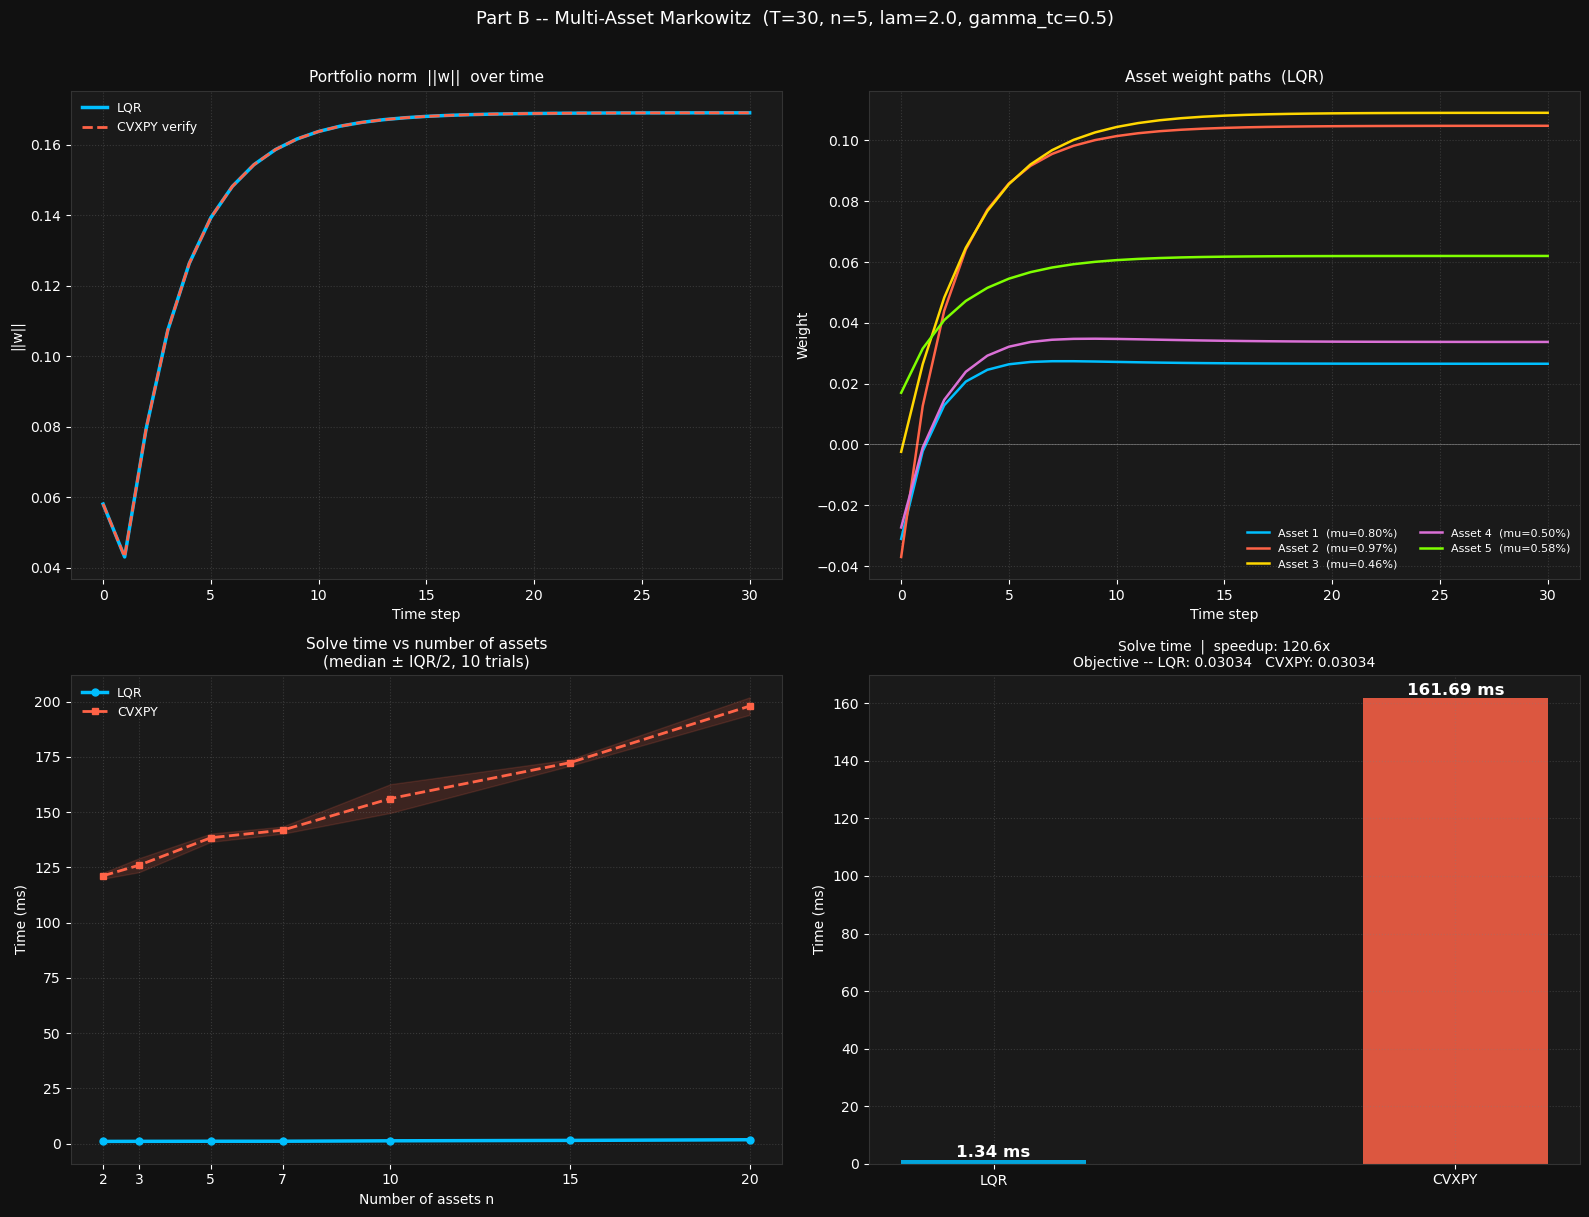

In [8]:
steps_mw = np.arange(T_mw + 1)
norm_lqr  = np.linalg.norm(w_lqr_mw, axis=1)
norm_cvx  = np.linalg.norm(w_cvx_mw, axis=1)

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#111111')

# ── 1: Portfolio norm ─────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
style_ax(ax1)
ax1.plot(steps_mw, norm_lqr, color=COLORS['dp'],  lw=2.5, label='LQR')
ax1.plot(steps_mw, norm_cvx, color=COLORS['cvx'], lw=2, ls='--', label='CVXPY verify')
ax1.set_title('Portfolio norm  ||w||  over time', color='white', fontsize=11)
ax1.set_xlabel('Time step', color='white'); ax1.set_ylabel('||w||', color='white')
ax1.legend(frameon=False, fontsize=9)

# ── 2: Individual asset weight paths (LQR) ────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
style_ax(ax2)
for i in range(n_assets):
    ax2.plot(steps_mw, w_lqr_mw[:, i],
             color=ASSET_PALETTE[i % len(ASSET_PALETTE)],
             lw=1.8, label=f'Asset {i+1}  (mu={mu[i]*100:.2f}%)')
ax2.axhline(0, color='white', lw=0.5, alpha=0.4)
ax2.set_title('Asset weight paths  (LQR)', color='white', fontsize=11)
ax2.set_xlabel('Time step', color='white'); ax2.set_ylabel('Weight', color='white')
ax2.legend(frameon=False, fontsize=8, ncol=2)

# ── 3: Scaling — median timing, fresh CVXPY, integer x-axis ──────────
ax3 = fig.add_subplot(2, 2, 3)
style_ax(ax3)

n_list   = [2, 3, 5, 7, 10, 15, 20]
N_TRIALS = 10
lqr_ms, cvx_ms = [], []

def _solve_cvxpy_scaling(n__, T__, mu__, Sig__, lam__, gtc__, w0__):
    """Isolated function scope — guarantees fresh CVXPY problem."""
    W__ = cp.Variable((T__+1, n__))
    U__ = cp.Variable((T__, n__))
    c__ = [W__[0] == w0__]
    cs  = 0
    for t__ in range(T__):
        c__.append(W__[t__+1] == W__[t__] + U__[t__])
        cs += (-mu__ @ W__[t__+1]
               + 0.5*lam__*cp.quad_form(W__[t__+1], Sig__)
               + 0.5*gtc__*cp.sum_squares(U__[t__]))
    cp.Problem(cp.Minimize(cs), c__).solve(
        solver=cp.OSQP, warm_starting=False)

for n_ in n_list:
    ts_lqr, ts_cvx = [], []
    for seed_ in range(N_TRIALS):
        rng_  = np.random.default_rng(seed_)
        L_    = rng_.standard_normal((n_, n_)) * 0.1
        Sig_  = L_ @ L_.T + np.diag(rng_.uniform(0.01, 0.05, n_))
        mu_   = rng_.uniform(0.002, 0.010, n_)
        w0_   = rng_.uniform(-0.05, 0.05, n_)
        na_   = n_ + 1
        A_    = np.eye(na_)
        B_    = np.vstack([np.eye(n_), np.zeros((1, n_))])
        Q_    = np.zeros((na_, na_))
        Q_[:n_,:n_]   = 0.5*lam*Sig_
        Q_[na_-1,:n_] = -0.5*mu_; Q_[:n_,na_-1] = -0.5*mu_
        R_    = 0.5*gamma_tc*np.eye(n_) + 0.5*lam*Sig_
        M_    = np.zeros((na_, n_))
        M_[:n_,:] = 0.5*lam*Sig_; M_[na_-1,:] = -0.5*mu_
        s0_   = np.append(w0_, 1.0)

        t0 = time.perf_counter()
        result_scale = solve_and_execute_lqr(T_mw, A_, B_, Q_, R_, M_, s0_)
        ts_lqr.append((time.perf_counter()-t0)*1000)

        t0 = time.perf_counter()
        _solve_cvxpy_scaling(n_, T_mw, mu_, Sig_, lam, gamma_tc, w0_)
        ts_cvx.append((time.perf_counter()-t0)*1000)

    lqr_med = np.median(ts_lqr)
    cvx_med = np.median(ts_cvx)
    lqr_iqr = (np.percentile(ts_lqr, 75) - np.percentile(ts_lqr, 25)) / 2
    cvx_iqr = (np.percentile(ts_cvx, 75) - np.percentile(ts_cvx, 25)) / 2
    lqr_ms.append((lqr_med, lqr_iqr))
    cvx_ms.append((cvx_med, cvx_iqr))

lqr_m = [x[0] for x in lqr_ms]; lqr_s = [x[1] for x in lqr_ms]
cvx_m = [x[0] for x in cvx_ms]; cvx_s = [x[1] for x in cvx_ms]
ax3.plot(n_list, lqr_m, color=COLORS['dp'],  lw=2.5, marker='o', ms=5, label='LQR')
ax3.plot(n_list, cvx_m, color=COLORS['cvx'], lw=2,   marker='s', ms=5, ls='--', label='CVXPY')
ax3.fill_between(n_list, np.array(lqr_m)-lqr_s, np.array(lqr_m)+lqr_s,
                 color=COLORS['dp'],  alpha=0.15)
ax3.fill_between(n_list, np.array(cvx_m)-cvx_s, np.array(cvx_m)+cvx_s,
                 color=COLORS['cvx'], alpha=0.15)
ax3.set_title('Solve time vs number of assets\n(median ± IQR/2, 10 trials)',
              color='white', fontsize=11)
ax3.set_xlabel('Number of assets n', color='white')
ax3.set_ylabel('Time (ms)', color='white')
ax3.set_xticks(n_list)
ax3.set_xticklabels([str(n) for n in n_list])
ax3.legend(frameon=False, fontsize=9)

# ── 4: Timing bar + objective ─────────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
style_ax(ax4)
bars = ax4.bar(['LQR','CVXPY'], [time_lqr_mw, time_cvx_mw],
               color=[COLORS['dp'], COLORS['cvx']], width=0.4, alpha=0.85)
for bar, t in zip(bars, [time_lqr_mw, time_cvx_mw]):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f'{t:.2f} ms', ha='center', va='bottom',
             color='white', fontsize=12, fontweight='bold')
ax4.set_title(
    f'Solve time  |  speedup: {speedup_mw:.1f}x\n'
    f'Objective -- LQR: {obj_lqr:.5f}   CVXPY: {obj_cvx:.5f}',
    color='white', fontsize=10)
ax4.set_ylabel('Time (ms)', color='white')

fig.suptitle(
    f'Part B -- Multi-Asset Markowitz  (T={T_mw}, n={n_assets}, lam={lam}, gamma_tc={gamma_tc})',
    color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('result/markowitz_results.png', dpi=150,
            bbox_inches='tight', facecolor='#111111')
print('Saved: result/markowitz_results.png')
plt.show()

# Part C — Given-Weight Extension

This section adds **given target-weight tracking** in the same demo style:

- **Single-asset** tracking to scalar target `w_given`
- **Multi-asset** tracking to vector target `w_given_vec`

Model form is kept close to the augmented-state setup used in Part B (`[w, 1]`) and solved by `solve_and_execute_lqr`, with CVXPY verification.

T=30, w0=0.0, w_given=0.25, kappa=0.04, gamma_tc=0.1, k_terminal=80.0
single-asset DP solve+execute: 1.21 ms
single-asset CVXPY solve: 103.49 ms, status=optimal
|w_T - w_given| (DP)    = 3.224643e-12
|w_T - w_given| (CVXPY) = 3.224643e-12
max |w_DP - w_CVX|      = 2.78e-17
Saved: result/givenweight_single_results.png


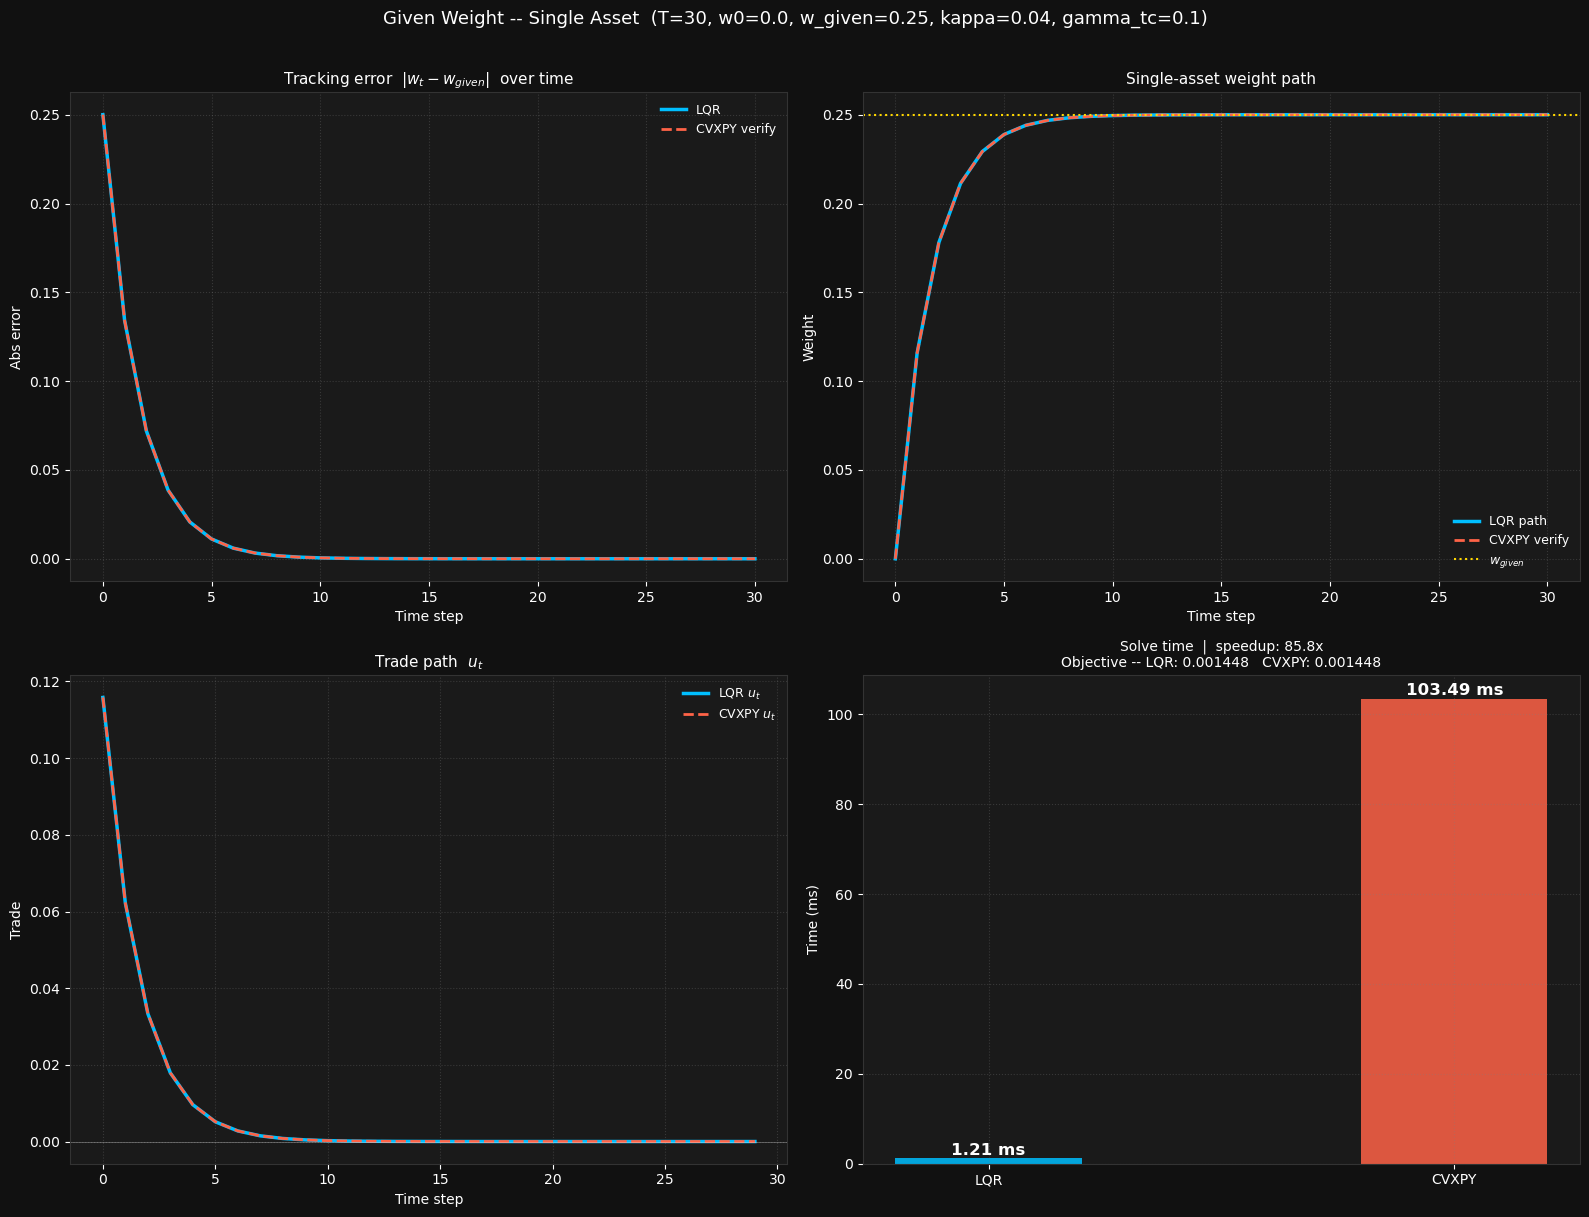

In [9]:
# ════════════════════════════════════════════════════════
#  Given Weight — Single Asset
# ════════════════════════════════════════════════════════
import cvxpy as cp
T_gw = 30
w0_gw = 0.0
w_given_gw = 0.25

# keep parameter style close to the first LQR block
gamma_gw = 1.0
sigma_sq_gw = 0.04
eta_gw = 0.1
k_terminal_gw = 80.0

kappa_gw = gamma_gw * sigma_sq_gw
gamma_tc_gw = eta_gw

# augmented state S=[w,1], control u=Δw
A_gw = np.eye(2)
B_gw = np.array([[1.0], [0.0]])

Q_gw = np.array([
    [0.5 * kappa_gw, -0.5 * kappa_gw * w_given_gw],
    [-0.5 * kappa_gw * w_given_gw, 0.5 * kappa_gw * (w_given_gw ** 2)],
])
R_gw = np.array([[0.5 * (kappa_gw + gamma_tc_gw)]])
M_gw = np.array([
    [0.5 * kappa_gw],
    [-0.5 * kappa_gw * w_given_gw],
])
P_T_gw = np.array([
    [0.5 * k_terminal_gw, -0.5 * k_terminal_gw * w_given_gw],
    [-0.5 * k_terminal_gw * w_given_gw, 0.5 * k_terminal_gw * (w_given_gw ** 2)],
])

s0_gw = np.array([w0_gw, 1.0])

print(
    f"T={T_gw}, w0={w0_gw}, w_given={w_given_gw}, "
    f"kappa={kappa_gw}, gamma_tc={gamma_tc_gw}, k_terminal={k_terminal_gw}"
)

# DP/LQR
t0 = time.perf_counter()
result_gw = solve_and_execute_lqr(
    T_gw, A_gw, B_gw, Q_gw, R_gw, M_gw, s0_gw, P_terminal=P_T_gw
)
time_lqr_gw = (time.perf_counter() - t0) * 1000
print(f"single-asset DP solve+execute: {time_lqr_gw:.2f} ms")

w_path_gw = result_gw.s_path[:, 0]
u_path_gw = result_gw.u_path[:, 0]

# CVXPY benchmark
W_gw = cp.Variable(T_gw + 1)
U_gw = cp.Variable(T_gw)
cons_gw = [W_gw[0] == w0_gw]
for t in range(T_gw):
    cons_gw.append(W_gw[t + 1] == W_gw[t] + U_gw[t])

cost_gw = 0
for t in range(T_gw):
    cost_gw += 0.5 * kappa_gw * cp.square(W_gw[t + 1] - w_given_gw)
    cost_gw += 0.5 * gamma_tc_gw * cp.square(U_gw[t])
cost_gw += 0.5 * k_terminal_gw * cp.square(W_gw[T_gw] - w_given_gw)

prob_gw = cp.Problem(cp.Minimize(cost_gw), cons_gw)
t0 = time.perf_counter()
prob_gw.solve(solver=cp.OSQP, verbose=False)
time_cvx_gw = (time.perf_counter() - t0) * 1000
print(f"single-asset CVXPY solve: {time_cvx_gw:.2f} ms, status={prob_gw.status}")

w_cvx_gw = np.asarray(W_gw.value)
u_cvx_gw = np.asarray(U_gw.value)
speedup_gw = time_cvx_gw / max(time_lqr_gw, 1e-12)

obj_gw_dp = (
    np.sum(0.5 * kappa_gw * (w_path_gw[1:] - w_given_gw) ** 2 + 0.5 * gamma_tc_gw * u_path_gw ** 2)
    + 0.5 * k_terminal_gw * (w_path_gw[-1] - w_given_gw) ** 2
)
obj_gw_cvx = (
    np.sum(0.5 * kappa_gw * (w_cvx_gw[1:] - w_given_gw) ** 2 + 0.5 * gamma_tc_gw * u_cvx_gw ** 2)
    + 0.5 * k_terminal_gw * (w_cvx_gw[-1] - w_given_gw) ** 2
)

print(f"|w_T - w_given| (DP)    = {abs(w_path_gw[-1] - w_given_gw):.6e}")
print(f"|w_T - w_given| (CVXPY) = {abs(w_cvx_gw[-1] - w_given_gw):.6e}")
print(f"max |w_DP - w_CVX|      = {np.max(np.abs(w_path_gw - w_cvx_gw)):.2e}")

# Visualization (Part-B-like 2x2 style)
steps_gw = np.arange(T_gw + 1)
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#111111')

# ── 1: Absolute tracking error over time ──────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
style_ax(ax1)
err_dp_gw = np.abs(w_path_gw - w_given_gw)
err_cvx_gw = np.abs(w_cvx_gw - w_given_gw)
ax1.plot(steps_gw, err_dp_gw, color=COLORS['dp'], lw=2.5, label='LQR')
ax1.plot(steps_gw, err_cvx_gw, color=COLORS['cvx'], lw=2, ls='--', label='CVXPY verify')
ax1.set_title(r'Tracking error  $|w_t - w_{given}|$  over time', color='white', fontsize=11)
ax1.set_xlabel('Time step', color='white'); ax1.set_ylabel('Abs error', color='white')
ax1.legend(frameon=False, fontsize=9)

# ── 2: Weight path to target ──────────────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
style_ax(ax2)
ax2.plot(steps_gw, w_path_gw, color=COLORS['dp'], lw=2.5, label='LQR path')
ax2.plot(steps_gw, w_cvx_gw, color=COLORS['cvx'], lw=2, ls='--', label='CVXPY verify')
ax2.axhline(w_given_gw, color=COLORS['target'], lw=1.5, ls=':', label=r'$w_{given}$')
ax2.set_title('Single-asset weight path', color='white', fontsize=11)
ax2.set_xlabel('Time step', color='white'); ax2.set_ylabel('Weight', color='white')
ax2.legend(frameon=False, fontsize=9)

# ── 3: Trade path comparison ──────────────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
style_ax(ax3)
ax3.plot(np.arange(T_gw), u_path_gw, color=COLORS['dp'], lw=2.5, label='LQR $u_t$')
ax3.plot(np.arange(T_gw), u_cvx_gw, color=COLORS['cvx'], lw=2, ls='--', label='CVXPY $u_t$')
ax3.axhline(0, color='white', lw=0.5, alpha=0.4)
ax3.set_title('Trade path  $u_t$', color='white', fontsize=11)
ax3.set_xlabel('Time step', color='white'); ax3.set_ylabel('Trade', color='white')
ax3.legend(frameon=False, fontsize=9)

# ── 4: Timing bar + objective ─────────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
style_ax(ax4)
bars = ax4.bar(['LQR', 'CVXPY'], [time_lqr_gw, time_cvx_gw],
               color=[COLORS['dp'], COLORS['cvx']], width=0.4, alpha=0.85)
for bar, t in zip(bars, [time_lqr_gw, time_cvx_gw]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{t:.2f} ms', ha='center', va='bottom',
             color='white', fontsize=12, fontweight='bold')
ax4.set_title(
    f'Solve time  |  speedup: {speedup_gw:.1f}x\n'
    f'Objective -- LQR: {obj_gw_dp:.6f}   CVXPY: {obj_gw_cvx:.6f}',
    color='white', fontsize=10)
ax4.set_ylabel('Time (ms)', color='white')

fig.suptitle(
    f'Given Weight -- Single Asset  (T={T_gw}, w0={w0_gw}, w_given={w_given_gw}, kappa={kappa_gw}, gamma_tc={gamma_tc_gw})',
    color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('result/givenweight_single_results.png', dpi=150,
            bbox_inches='tight', facecolor='#111111')
print('Saved: result/givenweight_single_results.png')
plt.show()

n=5 assets  T=30  kappa=2.0  gamma_tc=0.5
w_given      = [0.2545 0.1638 0.2774 0.2338 0.0706]
w0 (simple)  = [0.3146 0.2454 0.2535 0.0413 0.1452]
multi-asset DP solve+execute: 1.30 ms
multi-asset CVXPY solve: 118.42 ms, status=optimal
||w_T - w_given||_2 (DP)    = 2.775558e-17
||w_T - w_given||_2 (CVXPY) = 0.000000e+00
max |W_DP - W_CVX|          = 8.88e-16
Saved: result/givenweight_results.png


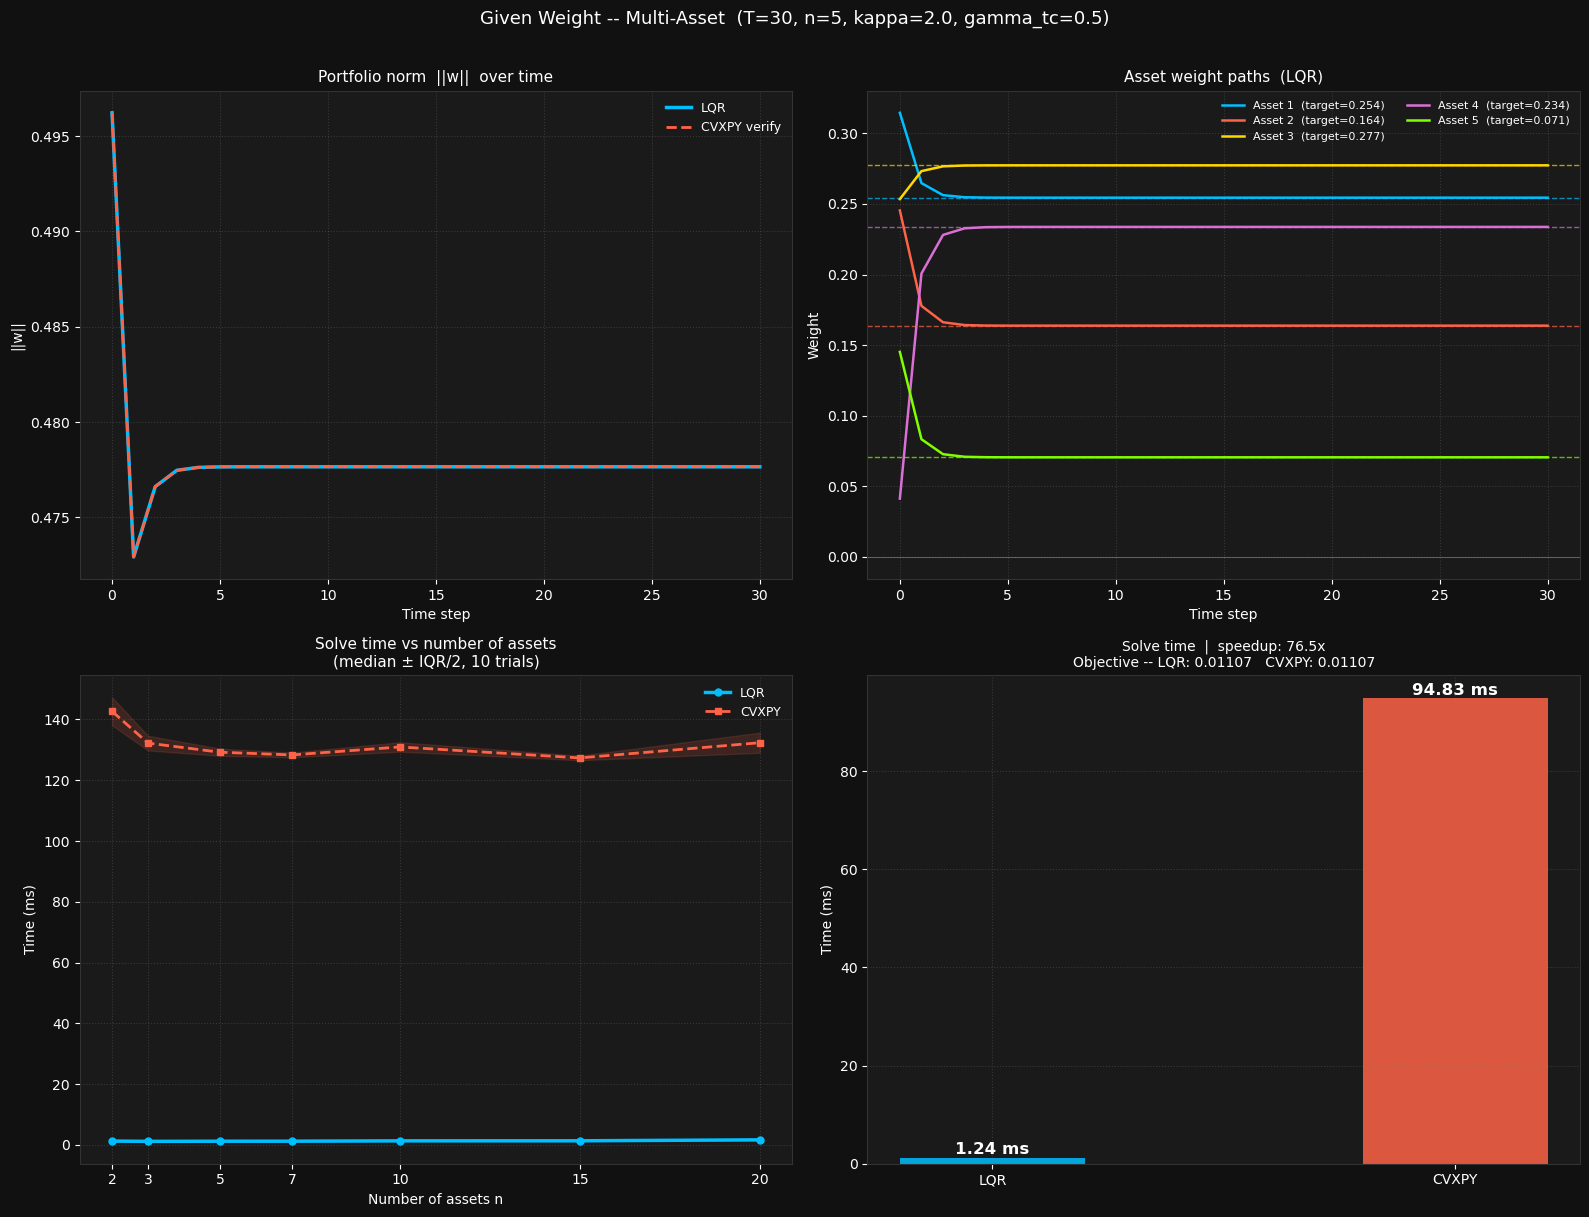

In [10]:
# ════════════════════════════════════════════════════════
#  Given Weight — Multi Asset
# ════════════════════════════════════════════════════════
T_gwm = 30
n_assets_gwm = 5
kappa_gwm = 2.0
gamma_tc_gwm = 0.5
k_terminal_gwm = 80.0
seed_gwm = 42

rng = np.random.default_rng(seed_gwm)

# given target vector (same random-parameter style as Markowitz block)
w_given_gwm = rng.uniform(0.05, 0.35, n_assets_gwm)
w_given_gwm = w_given_gwm / np.sum(w_given_gwm)

# simple initialization (no optimization): random long-only then normalize
w0_gwm = rng.uniform(0.0, 0.40, n_assets_gwm)
w0_gwm = w0_gwm / np.sum(w0_gwm)

n = n_assets_gwm
na = n + 1

A_gwm = np.eye(na)
B_gwm = np.vstack([np.eye(n), np.zeros((1, n))])

Q_gwm = np.zeros((na, na))
Q_gwm[:n, :n] = 0.5 * kappa_gwm * np.eye(n)
Q_gwm[n, :n] = -0.5 * kappa_gwm * w_given_gwm
Q_gwm[:n, n] = -0.5 * kappa_gwm * w_given_gwm
Q_gwm[n, n] = 0.5 * kappa_gwm * float(w_given_gwm @ w_given_gwm)

R_gwm = 0.5 * (kappa_gwm + gamma_tc_gwm) * np.eye(n)

M_gwm = np.zeros((na, n))
M_gwm[:n, :] = 0.5 * kappa_gwm * np.eye(n)
M_gwm[n, :] = -0.5 * kappa_gwm * w_given_gwm

P_T_gwm = np.zeros((na, na))
P_T_gwm[:n, :n] = 0.5 * k_terminal_gwm * np.eye(n)
P_T_gwm[n, :n] = -0.5 * k_terminal_gwm * w_given_gwm
P_T_gwm[:n, n] = -0.5 * k_terminal_gwm * w_given_gwm
P_T_gwm[n, n] = 0.5 * k_terminal_gwm * float(w_given_gwm @ w_given_gwm)

s0_gwm = np.append(w0_gwm, 1.0)

print(f"n={n_assets_gwm} assets  T={T_gwm}  kappa={kappa_gwm}  gamma_tc={gamma_tc_gwm}")
print(f"w_given      = {w_given_gwm.round(4)}")
print(f"w0 (simple)  = {w0_gwm.round(4)}")

# DP/LQR
t0 = time.perf_counter()
result_gwm = solve_and_execute_lqr(
    T_gwm, A_gwm, B_gwm, Q_gwm, R_gwm, M_gwm, s0_gwm, P_terminal=P_T_gwm
)
print(f"multi-asset DP solve+execute: {(time.perf_counter() - t0) * 1000:.2f} ms")

W_path_gwm = result_gwm.s_path[:, :n]
err_gwm = np.linalg.norm(W_path_gwm - w_given_gwm, axis=1)

# CVXPY benchmark
Wm = cp.Variable((T_gwm + 1, n))
Um = cp.Variable((T_gwm, n))
cons_m = [Wm[0] == w0_gwm]
for t in range(T_gwm):
    cons_m.append(Wm[t + 1] == Wm[t] + Um[t])

cost_m = 0
for t in range(T_gwm):
    cost_m += 0.5 * kappa_gwm * cp.sum_squares(Wm[t + 1] - w_given_gwm)
    cost_m += 0.5 * gamma_tc_gwm * cp.sum_squares(Um[t])
cost_m += 0.5 * k_terminal_gwm * cp.sum_squares(Wm[T_gwm] - w_given_gwm)

prob_m = cp.Problem(cp.Minimize(cost_m), cons_m)
t0 = time.perf_counter()
prob_m.solve(solver=cp.OSQP, verbose=False)
print(f"multi-asset CVXPY solve: {(time.perf_counter() - t0) * 1000:.2f} ms, status={prob_m.status}")

W_cvx_gwm = np.asarray(Wm.value)
err_cvx_gwm = np.linalg.norm(W_cvx_gwm - w_given_gwm, axis=1)

print(f"||w_T - w_given||_2 (DP)    = {err_gwm[-1]:.6e}")
print(f"||w_T - w_given||_2 (CVXPY) = {err_cvx_gwm[-1]:.6e}")
print(f"max |W_DP - W_CVX|          = {np.max(np.abs(W_path_gwm - W_cvx_gwm)):.2e}")

# Visualization (same style as Part B / Markowitz block)
steps_gwm = np.arange(T_gwm + 1)
norm_dp_gwm = np.linalg.norm(W_path_gwm, axis=1)
norm_cvx_gwm = np.linalg.norm(W_cvx_gwm, axis=1)
obj_dp_gwm = (
    np.sum(0.5 * kappa_gwm * np.sum((W_path_gwm[1:] - w_given_gwm) ** 2, axis=1)
           + 0.5 * gamma_tc_gwm * np.sum(np.asarray(result_gwm.u_path) ** 2, axis=1))
    + 0.5 * k_terminal_gwm * np.sum((W_path_gwm[-1] - w_given_gwm) ** 2)
)
obj_cvx_gwm = (
    np.sum(0.5 * kappa_gwm * np.sum((W_cvx_gwm[1:] - w_given_gwm) ** 2, axis=1)
           + 0.5 * gamma_tc_gwm * np.sum(np.asarray(Um.value) ** 2, axis=1))
    + 0.5 * k_terminal_gwm * np.sum((W_cvx_gwm[-1] - w_given_gwm) ** 2)
)

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#111111')

# ── 1: Portfolio norm ─────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
style_ax(ax1)
ax1.plot(steps_gwm, norm_dp_gwm, color=COLORS['dp'], lw=2.5, label='LQR')
ax1.plot(steps_gwm, norm_cvx_gwm, color=COLORS['cvx'], lw=2, ls='--', label='CVXPY verify')
ax1.set_title('Portfolio norm  ||w||  over time', color='white', fontsize=11)
ax1.set_xlabel('Time step', color='white'); ax1.set_ylabel('||w||', color='white')
ax1.legend(frameon=False, fontsize=9)

# ── 2: Individual asset weight paths (LQR) ────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
style_ax(ax2)
for i in range(n_assets_gwm):
    c = ASSET_PALETTE[i % len(ASSET_PALETTE)]
    ax2.plot(steps_gwm, W_path_gwm[:, i], color=c, lw=1.8, label=f'Asset {i+1}  (target={w_given_gwm[i]:.3f})')
    ax2.axhline(w_given_gwm[i], color=c, ls='--', lw=1, alpha=0.7)
ax2.axhline(0, color='white', lw=0.5, alpha=0.4)
ax2.set_title('Asset weight paths  (LQR)', color='white', fontsize=11)
ax2.set_xlabel('Time step', color='white'); ax2.set_ylabel('Weight', color='white')
ax2.legend(frameon=False, fontsize=8, ncol=2)

# ── 3: Scaling — median timing, fresh CVXPY, integer x-axis ──────────
ax3 = fig.add_subplot(2, 2, 3)
style_ax(ax3)

n_list = [2, 3, 5, 7, 10, 15, 20]
N_TRIALS = 10
lqr_ms, cvx_ms = [], []

def _solve_cvxpy_scaling_given(n__, T__, w_given__, kappa__, gamma_tc__, k_terminal__, w0__):
    W__ = cp.Variable((T__ + 1, n__))
    U__ = cp.Variable((T__, n__))
    c__ = [W__[0] == w0__]
    cs = 0
    for t__ in range(T__):
        c__.append(W__[t__ + 1] == W__[t__] + U__[t__])
        cs += (0.5 * kappa__ * cp.sum_squares(W__[t__ + 1] - w_given__)
               + 0.5 * gamma_tc__ * cp.sum_squares(U__[t__]))
    cs += 0.5 * k_terminal__ * cp.sum_squares(W__[T__] - w_given__)
    cp.Problem(cp.Minimize(cs), c__).solve(solver=cp.OSQP, warm_starting=False)

for n_ in n_list:
    ts_lqr, ts_cvx = [], []
    for seed_ in range(N_TRIALS):
        rng_ = np.random.default_rng(seed_)
        w_given_ = rng_.uniform(0.05, 0.35, n_)
        w_given_ = w_given_ / np.sum(w_given_)
        w0_ = rng_.uniform(0.0, 0.40, n_)
        w0_ = w0_ / np.sum(w0_)

        na_ = n_ + 1
        A_ = np.eye(na_)
        B_ = np.vstack([np.eye(n_), np.zeros((1, n_))])

        Q_ = np.zeros((na_, na_))
        Q_[:n_, :n_] = 0.5 * kappa_gwm * np.eye(n_)
        Q_[na_ - 1, :n_] = -0.5 * kappa_gwm * w_given_
        Q_[:n_, na_ - 1] = -0.5 * kappa_gwm * w_given_
        Q_[na_ - 1, na_ - 1] = 0.5 * kappa_gwm * float(w_given_ @ w_given_)

        R_ = 0.5 * (kappa_gwm + gamma_tc_gwm) * np.eye(n_)

        M_ = np.zeros((na_, n_))
        M_[:n_, :] = 0.5 * kappa_gwm * np.eye(n_)
        M_[na_ - 1, :] = -0.5 * kappa_gwm * w_given_

        P_ = np.zeros((na_, na_))
        P_[:n_, :n_] = 0.5 * k_terminal_gwm * np.eye(n_)
        P_[na_ - 1, :n_] = -0.5 * k_terminal_gwm * w_given_
        P_[:n_, na_ - 1] = -0.5 * k_terminal_gwm * w_given_
        P_[na_ - 1, na_ - 1] = 0.5 * k_terminal_gwm * float(w_given_ @ w_given_)

        s0_ = np.append(w0_, 1.0)

        t0 = time.perf_counter()
        _ = solve_and_execute_lqr(T_gwm, A_, B_, Q_, R_, M_, s0_, P_terminal=P_)
        ts_lqr.append((time.perf_counter() - t0) * 1000)

        t0 = time.perf_counter()
        _solve_cvxpy_scaling_given(n_, T_gwm, w_given_, kappa_gwm, gamma_tc_gwm, k_terminal_gwm, w0_)
        ts_cvx.append((time.perf_counter() - t0) * 1000)

    lqr_med = np.median(ts_lqr)
    cvx_med = np.median(ts_cvx)
    lqr_iqr = (np.percentile(ts_lqr, 75) - np.percentile(ts_lqr, 25)) / 2
    cvx_iqr = (np.percentile(ts_cvx, 75) - np.percentile(ts_cvx, 25)) / 2
    lqr_ms.append((lqr_med, lqr_iqr))
    cvx_ms.append((cvx_med, cvx_iqr))

lqr_m = [x[0] for x in lqr_ms]; lqr_s = [x[1] for x in lqr_ms]
cvx_m = [x[0] for x in cvx_ms]; cvx_s = [x[1] for x in cvx_ms]

ax3.plot(n_list, lqr_m, color=COLORS['dp'], lw=2.5, marker='o', ms=5, label='LQR')
ax3.plot(n_list, cvx_m, color=COLORS['cvx'], lw=2, marker='s', ms=5, ls='--', label='CVXPY')
ax3.fill_between(n_list, np.array(lqr_m) - lqr_s, np.array(lqr_m) + lqr_s, color=COLORS['dp'], alpha=0.15)
ax3.fill_between(n_list, np.array(cvx_m) - cvx_s, np.array(cvx_m) + cvx_s, color=COLORS['cvx'], alpha=0.15)
ax3.set_title('Solve time vs number of assets\n(median ± IQR/2, 10 trials)', color='white', fontsize=11)
ax3.set_xlabel('Number of assets n', color='white')
ax3.set_ylabel('Time (ms)', color='white')
ax3.set_xticks(n_list)
ax3.set_xticklabels([str(n) for n in n_list])
ax3.legend(frameon=False, fontsize=9)

# ── 4: Timing bar + objective ─────────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
style_ax(ax4)

t0 = time.perf_counter()
_ = solve_and_execute_lqr(T_gwm, A_gwm, B_gwm, Q_gwm, R_gwm, M_gwm, s0_gwm, P_terminal=P_T_gwm)
time_lqr_gwm = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
cp.Problem(cp.Minimize(cost_m), cons_m).solve(solver=cp.OSQP, verbose=False)
time_cvx_gwm = (time.perf_counter() - t0) * 1000

bars = ax4.bar(['LQR', 'CVXPY'], [time_lqr_gwm, time_cvx_gwm],
               color=[COLORS['dp'], COLORS['cvx']], width=0.4, alpha=0.85)
for bar, t in zip(bars, [time_lqr_gwm, time_cvx_gwm]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{t:.2f} ms', ha='center', va='bottom',
             color='white', fontsize=12, fontweight='bold')
ax4.set_title(
    f'Solve time  |  speedup: {time_cvx_gwm / max(time_lqr_gwm, 1e-12):.1f}x\n'
    f'Objective -- LQR: {obj_dp_gwm:.5f}   CVXPY: {obj_cvx_gwm:.5f}',
    color='white', fontsize=10)
ax4.set_ylabel('Time (ms)', color='white')

fig.suptitle(
    f'Given Weight -- Multi-Asset  (T={T_gwm}, n={n_assets_gwm}, kappa={kappa_gwm}, gamma_tc={gamma_tc_gwm})',
    color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('result/givenweight_results.png', dpi=150,
            bbox_inches='tight', facecolor='#111111')
print('Saved: result/givenweight_results.png')
plt.show()